# 3_rBergomi_ioexp

IO 市场（沪深300股指期权）rBergomi 高精度实验入口。

本 notebook 仅使用 `ioexp_*` 新模块，不改动原有实验链路。

In [12]:
import os
import sys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

sys.path.append('../models')

from OptionDataFetcher import OptionDataFetcher
from ioexp_data_contract import IOSliceConfig
from ioexp_runner import IOExperimentRunner, RunnerConfig


In [13]:
# # 先检查真实列名（建议先用1天）
# underlying_order_book_id = '000300.XSHG'
# start_date = '20240102'
# fetcher = OptionDataFetcher()
# fetcher.init_connection(os.environ.get('RQDATAC_LICENSE') or os.environ.get('RQ_API_KEY'))
# schema_info = fetcher.inspect_option_schema(underlying_order_book_id=underlying_order_book_id, date=start_date)
# schema_info

In [14]:
# 一键：拉取 + 清洗 + 落盘 + 送入 runner
# 使用前请先在环境变量设置 RQDATAC_LICENSE，或在 init_connection 中传入 license
underlying_order_book_id = '000300.XSHG'
start_date = '20240101'
end_date = '20240131'
output_csv = Path('../data/io_option_cross_section_20240101_20240131.csv')

if output_csv.exists():
    raw_df = pd.read_csv(output_csv)
    print(f'Loaded cached option panel: {output_csv}')
else:
    fetcher = OptionDataFetcher()
    fetcher.init_connection(os.environ.get('RQDATAC_LICENSE') or os.environ.get('RQ_API_KEY'))
    raw_df = fetcher.fetch_option_panel_for_underlying(
        underlying_order_book_id=underlying_order_book_id,
        start_date=start_date,
        end_date=end_date,
        risk_free_rate=0.02,
        dividend_yield=0.0,
        apply_cleaning=True,
        save_path=str(output_csv),
        include_api_iv=False,
        verbose=True,
        min_days_to_expiry=5,
        min_volume=0.0,
        max_abs_log_moneyness=None,
    )

# 短样本调试窗口（避免默认420交易日要求）
cfg = RunnerConfig(
    data=IOSliceConfig(
        train_days=10,
        valid_days=5,
        test_days=5,
        step_days=5,
        min_total_days=20,
    )
)
runner = IOExperimentRunner(cfg=cfg)
prepared = runner.prepare_dataset(raw_df)
print('prepared rows:', len(prepared), 'unique trade days:', prepared['trade_date'].nunique())
prepared.head()

Loaded cached option panel: ../data/io_option_cross_section_20240101_20240131.csv
prepared rows: 3771 unique trade days: 22


,trade_date,maturity,strike,option_type,market_price,underlying,r,q,forward,log_moneyness,tau_days,maturity_bucket,moneyness_bucket
0,2024-01-02,0.131507,2950.0,call,464.0,3386.3522,0.02,0.0,3395.270493,-0.140578,33,mid,ITM_call_OTM_put
1,2024-01-02,0.131507,2950.0,put,1.3,3386.3522,0.02,0.0,3395.270493,-0.140578,33,mid,ITM_call_OTM_put
2,2024-01-02,0.131507,3000.0,call,413.5,3386.3522,0.02,0.0,3395.270493,-0.123771,33,mid,ITM_call_OTM_put
3,2024-01-02,0.131507,3000.0,put,1.9,3386.3522,0.02,0.0,3395.270493,-0.123771,33,mid,ITM_call_OTM_put
4,2024-01-02,0.131507,3050.0,call,395.8,3386.3522,0.02,0.0,3395.270493,-0.107242,33,mid,ITM_call_OTM_put


In [39]:
# 可选：传入 RFSV 预测文件路径，触发 rBergomi_plain vs rBergomi_with_rfsv_prior 消融
# 缓存机制：首次运行慢，之后直接加载，不必每次重跑
rfsv_path = Path('../data/rfsv_predictions_sample.csv')
rfsv_arg = str(rfsv_path) if rfsv_path.exists() else None

result_cache = Path('../data/ioexp_result_cache.pkl')
if result_cache.exists():
    with open(result_cache, 'rb') as f:
        result = pickle.load(f)
    print(f'Loaded cached result: {result_cache}')
else:
    result = runner.run_single_test_window(
        prepared_df=prepared,
        rfsv_pred_path=rfsv_arg,
        H_init=0.1,
        eta_init=1.0,
        rho_init=-0.7,
    )
    with open(result_cache, 'wb') as f:
        pickle.dump(result, f)
    print(f'Saved result cache: {result_cache}')

result['summary']

Loaded cached result: ../data/ioexp_result_cache.pkl


,iv_rmse,iv_mae,price_rmse,price_mae,n,skew_error,atm_term_error,model
0,0.077232,0.059339,32.389239,25.339513,1024,0.051870,0.037864,sabr_hagan
1,0.077271,0.059671,32.347836,25.338512,1024,0.049419,0.037478,localvol_quadratic_iv
2,0.084264,0.064396,33.676280,26.574162,1024,0.125108,0.040836,heston_cf
3,0.097707,0.059958,39.924752,25.748015,1024,0.303834,0.039134,rbergomi_plain
4,0.097739,0.060035,40.104737,25.784527,1024,0.307790,0.039111,rbergomi_with_rfsv_prior
5,0.106319,0.065180,38.562548,25.745352,1024,0.333988,0.041295,bs_flat


In [40]:
result['atm_comparison'].head() if result['atm_comparison'] is not None else None

---

In [41]:
# 诊断A：准备分析数据（with_rfsv_prior）
import numpy as np

diagnose_df = result['rbergomi_test_df_with_rfsv_prior'].copy()
diagnose_df = diagnose_df.dropna(
    subset=['trade_date', 'maturity', 'log_moneyness', 'market_iv', 'model_iv', 'option_type']
)
diagnose_df['trade_date'] = pd.to_datetime(diagnose_df['trade_date']).dt.normalize()

print('diagnose rows:', len(diagnose_df))
print('trade dates:', diagnose_df['trade_date'].nunique(), 'maturities:', diagnose_df['maturity'].nunique())

diagnose rows: 1024
trade dates: 5 maturities: 30


slice rows: 41 date: 2024-01-23 00:00:00 tau: 0.073972602739726


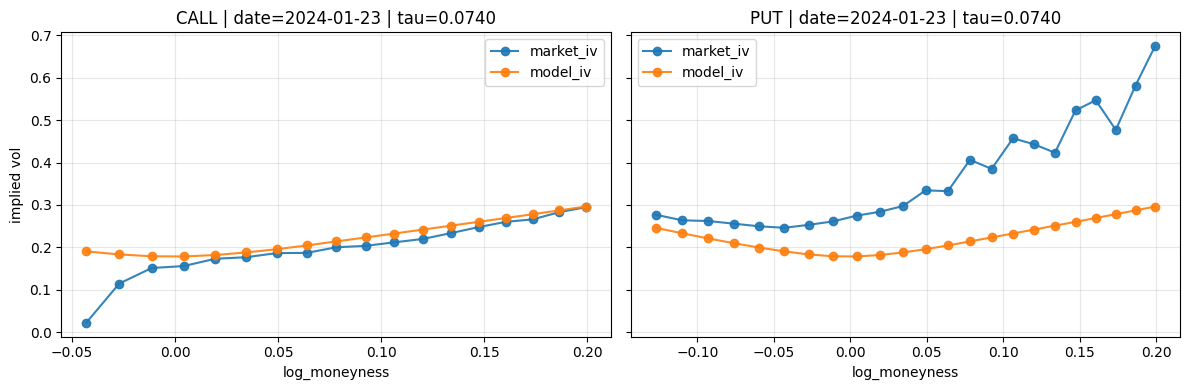

In [42]:
# 诊断B：单日+单期限分 call/put 的 smile
pick_date = sorted(diagnose_df['trade_date'].unique())[0]
pick_tau = sorted(diagnose_df.loc[diagnose_df['trade_date'] == pick_date, 'maturity'].unique())[0]

slice_df = diagnose_df[(diagnose_df['trade_date'] == pick_date) & (diagnose_df['maturity'] == pick_tau)].copy()
print('slice rows:', len(slice_df), 'date:', pick_date, 'tau:', pick_tau)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, opt in enumerate(['call', 'put']):
    part = slice_df[slice_df['option_type'].str.lower() == opt].sort_values('log_moneyness')
    if part.empty:
        ax[i].set_title(f'{opt.upper()} (empty)')
        continue
    ax[i].plot(part['log_moneyness'], part['market_iv'], 'o-', label='market_iv', alpha=0.9)
    ax[i].plot(part['log_moneyness'], part['model_iv'], 'o-', label='model_iv', alpha=0.9)
    ax[i].set_title(f'{opt.upper()} | date={pick_date.date()} | tau={pick_tau:.4f}')
    ax[i].set_xlabel('log_moneyness')
    ax[i].grid(alpha=0.3)
    if i == 0:
        ax[i].set_ylabel('implied vol')
    ax[i].legend()

plt.tight_layout()
plt.show()

In [43]:
# 诊断C：检查“同一log_moneyness多IV”来源
xdup_df = slice_df.copy()
xdup_df['lm_bin'] = xdup_df['log_moneyness'].round(6)

dup_stats = (
    xdup_df.groupby('lm_bin')
    .agg(
        n=('market_iv', 'size'),
        n_call=('option_type', lambda x: (x.str.lower() == 'call').sum()),
        n_put=('option_type', lambda x: (x.str.lower() == 'put').sum()),
        market_iv_std=('market_iv', 'std'),
        model_iv_std=('model_iv', 'std'),
    )
    .reset_index()
    .sort_values('n', ascending=False)
)

dup_stats.head(20)

,lm_bin,n,n_call,n_put,market_iv_std,model_iv_std
11,0.049216,2,1,1,0.104679,3.181244e-08
12,0.063814,2,1,1,0.103019,3.974024e-08
21,0.186417,2,1,1,0.211217,3.331045e-07
20,0.173513,2,1,1,0.149262,2.697077e-07
19,0.160441,2,1,1,0.202812,2.161090e-07
18,0.147196,2,1,1,0.194795,1.715890e-07
17,0.133773,2,1,1,0.134146,1.351054e-07
16,0.120167,2,1,1,0.157882,1.059408e-07
15,0.106374,2,1,1,0.173562,8.273950e-08
14,0.092388,2,1,1,0.128400,6.443520e-08


In [44]:
# 诊断D：量化 call/put 拟合误差，并比较 plain vs with_rfsv_prior

def summarize_side(df_side: pd.DataFrame, model_name: str) -> pd.DataFrame:
    z = df_side.dropna(subset=['market_iv', 'model_iv', 'option_type']).copy()
    z['iv_error'] = z['model_iv'] - z['market_iv']
    out = (
        z.groupby(z['option_type'].str.lower())['iv_error']
        .apply(
            lambda x: pd.Series(
                {
                    'n': len(x),
                    'iv_rmse': np.sqrt(np.mean(np.square(x))),
                    'iv_mae': np.mean(np.abs(x)),
                    'bias': np.mean(x),
                }
            )
        )
        .unstack()
    )
    out['model'] = model_name
    return out.reset_index().rename(columns={'option_type': 'side'})

cmp_side = pd.concat(
    [
        summarize_side(result['rbergomi_test_df_plain'], 'plain'),
        summarize_side(result['rbergomi_test_df_with_rfsv_prior'], 'with_rfsv_prior'),
    ],
    ignore_index=True,
)
cmp_side

,side,n,iv_rmse,iv_mae,bias,model
0,call,495.0,0.052933,0.029952,0.019894,plain
1,put,529.0,0.125927,0.088035,-0.085867,plain
2,call,495.0,0.052879,0.029677,0.019559,with_rfsv_prior
3,put,529.0,0.125997,0.088442,-0.086172,with_rfsv_prior


---

Selected 5 dates to plot


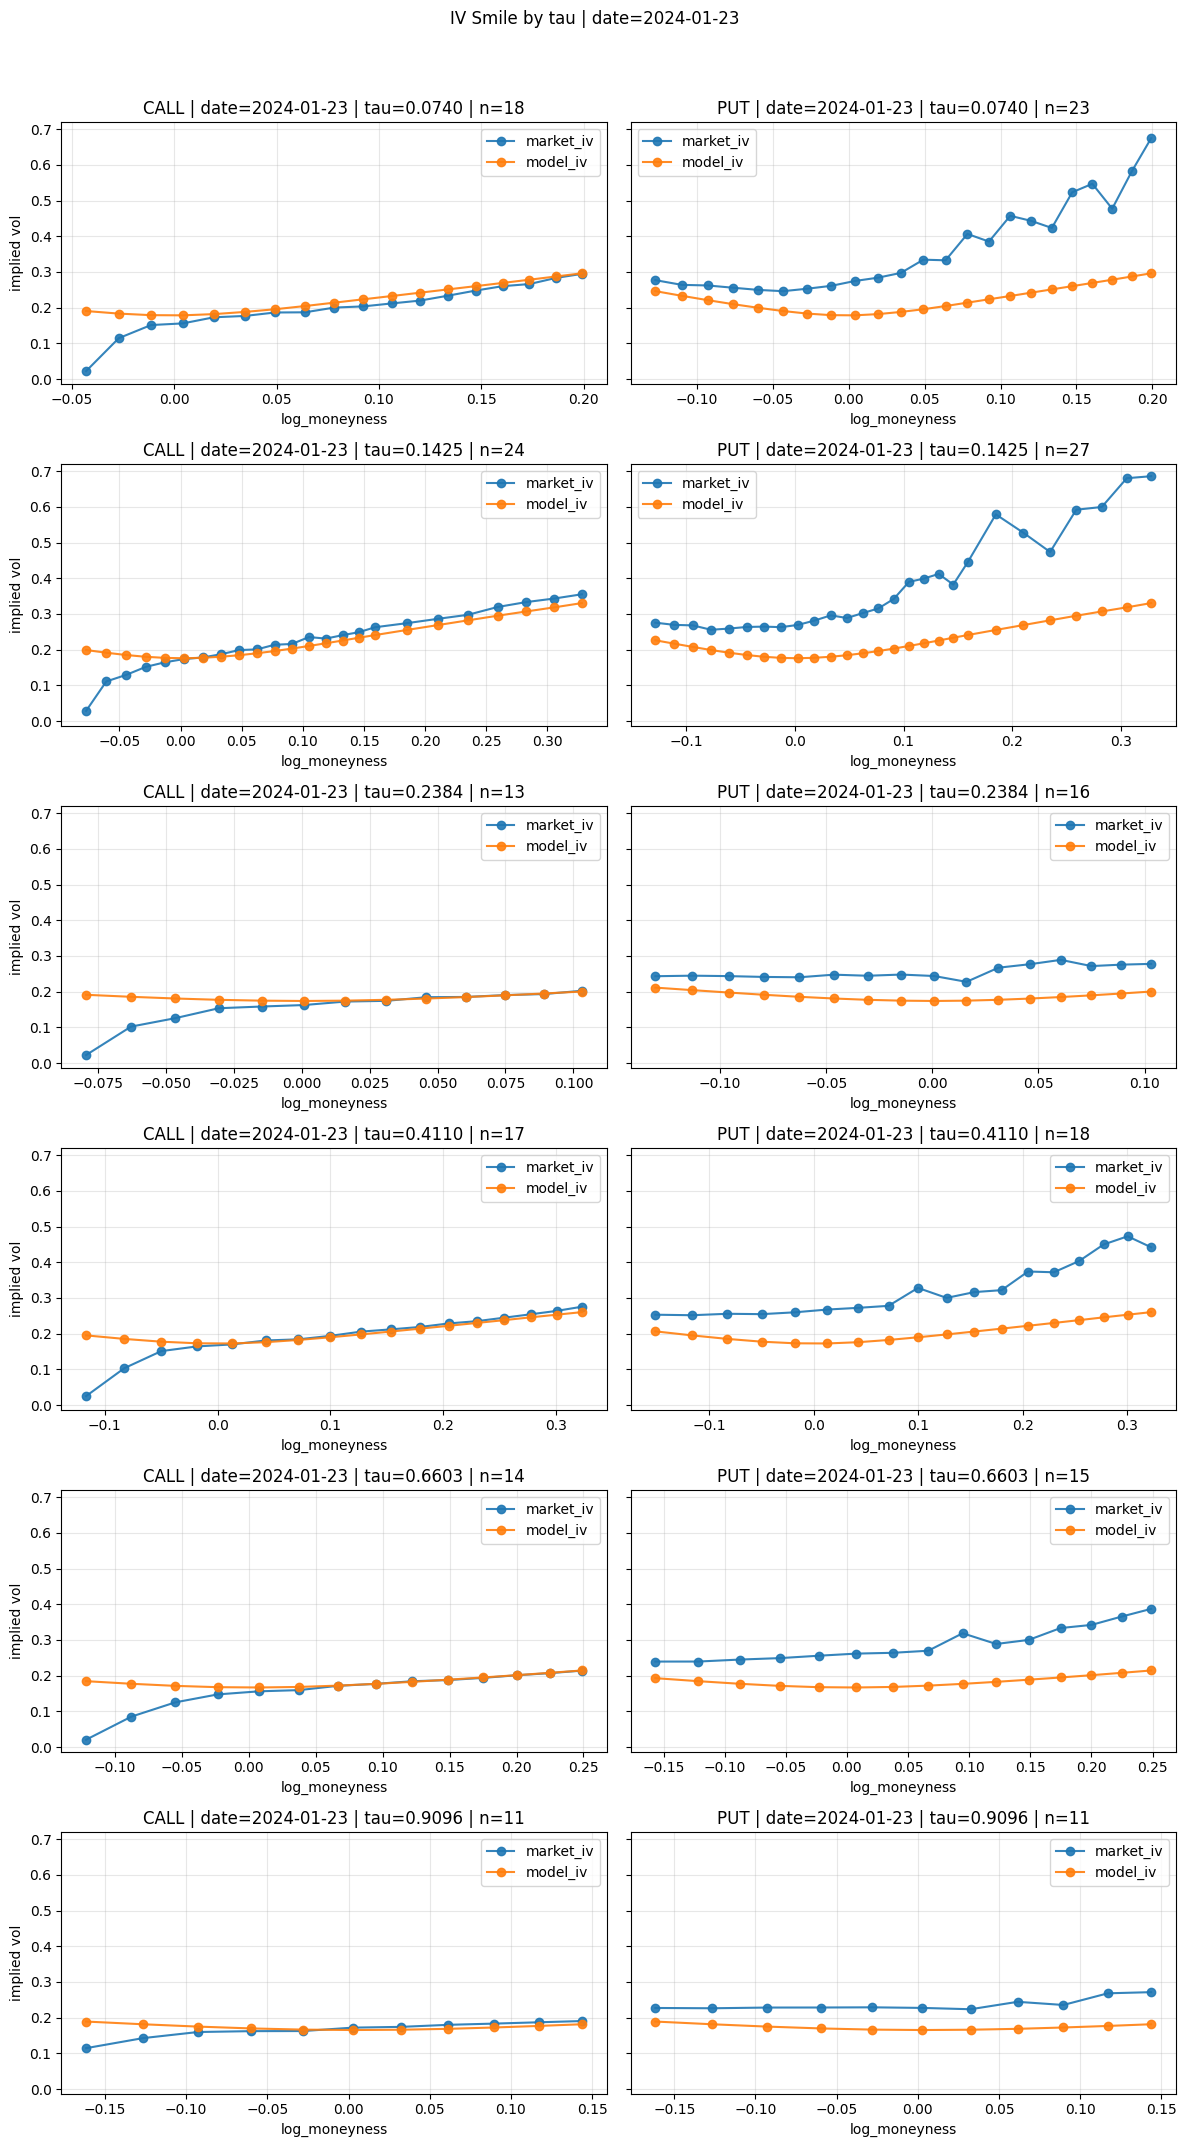

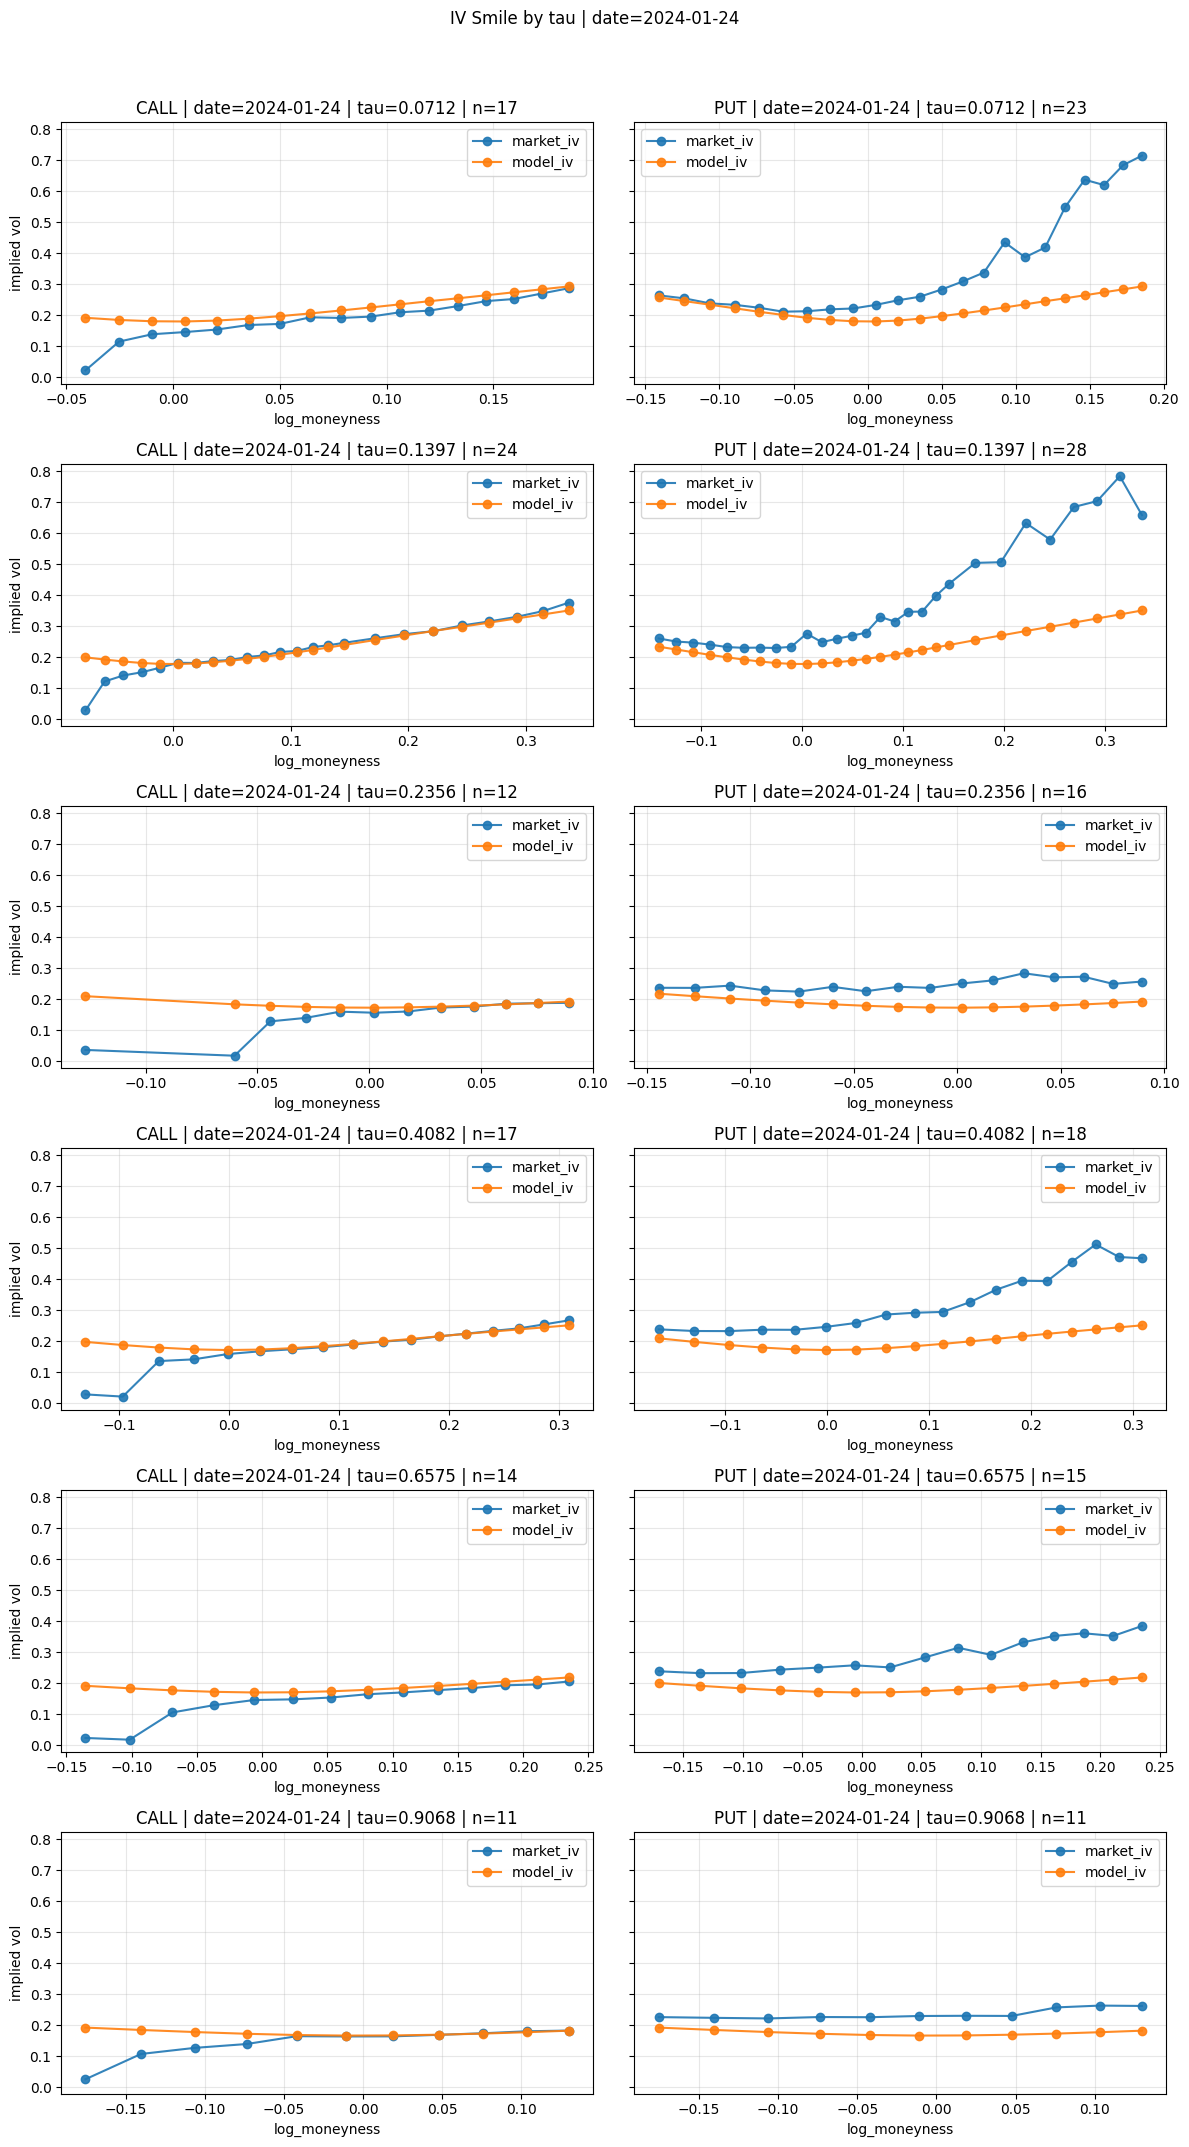

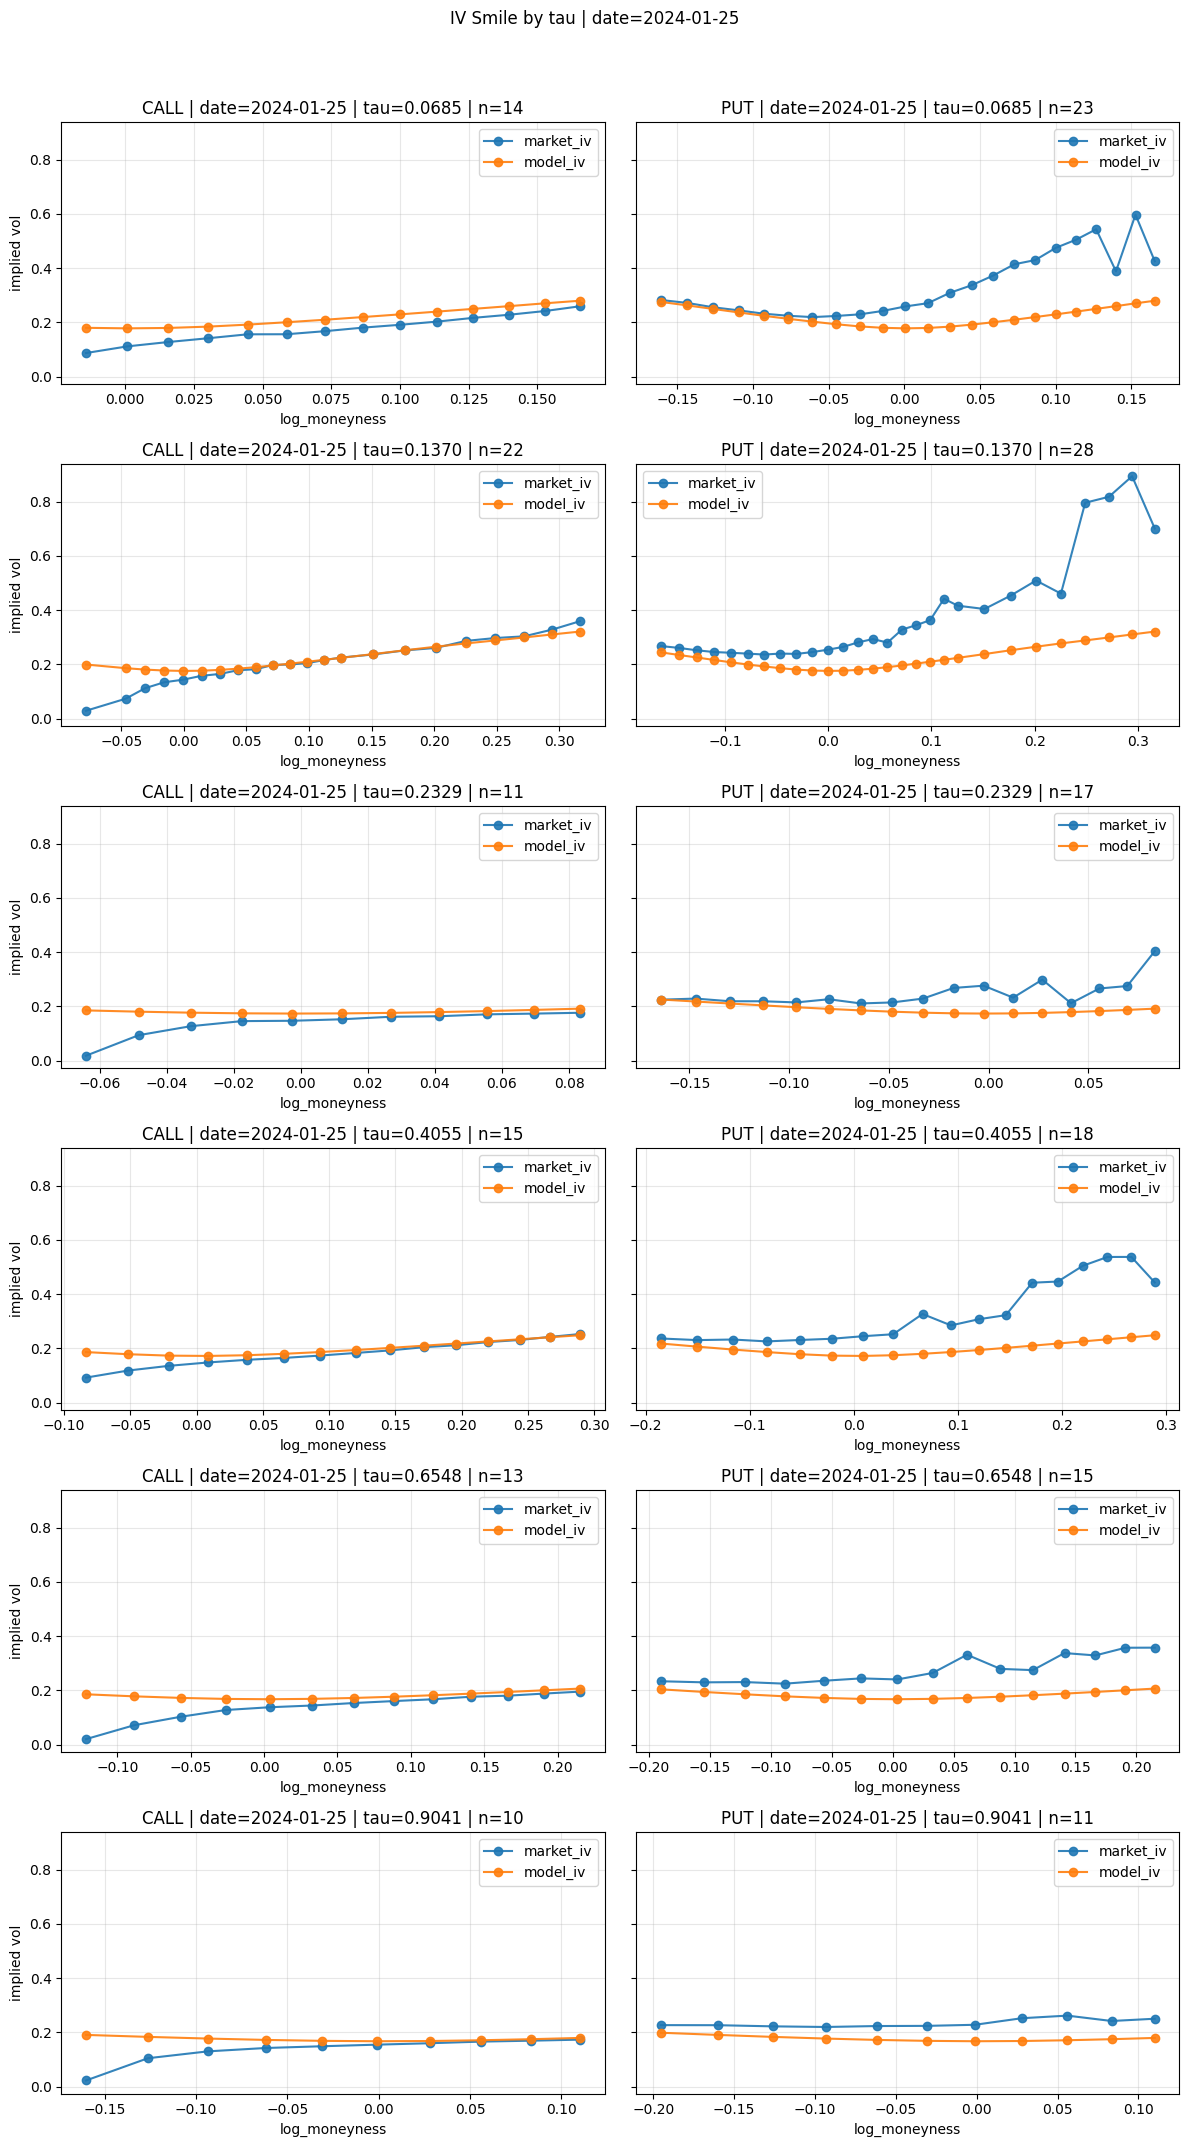

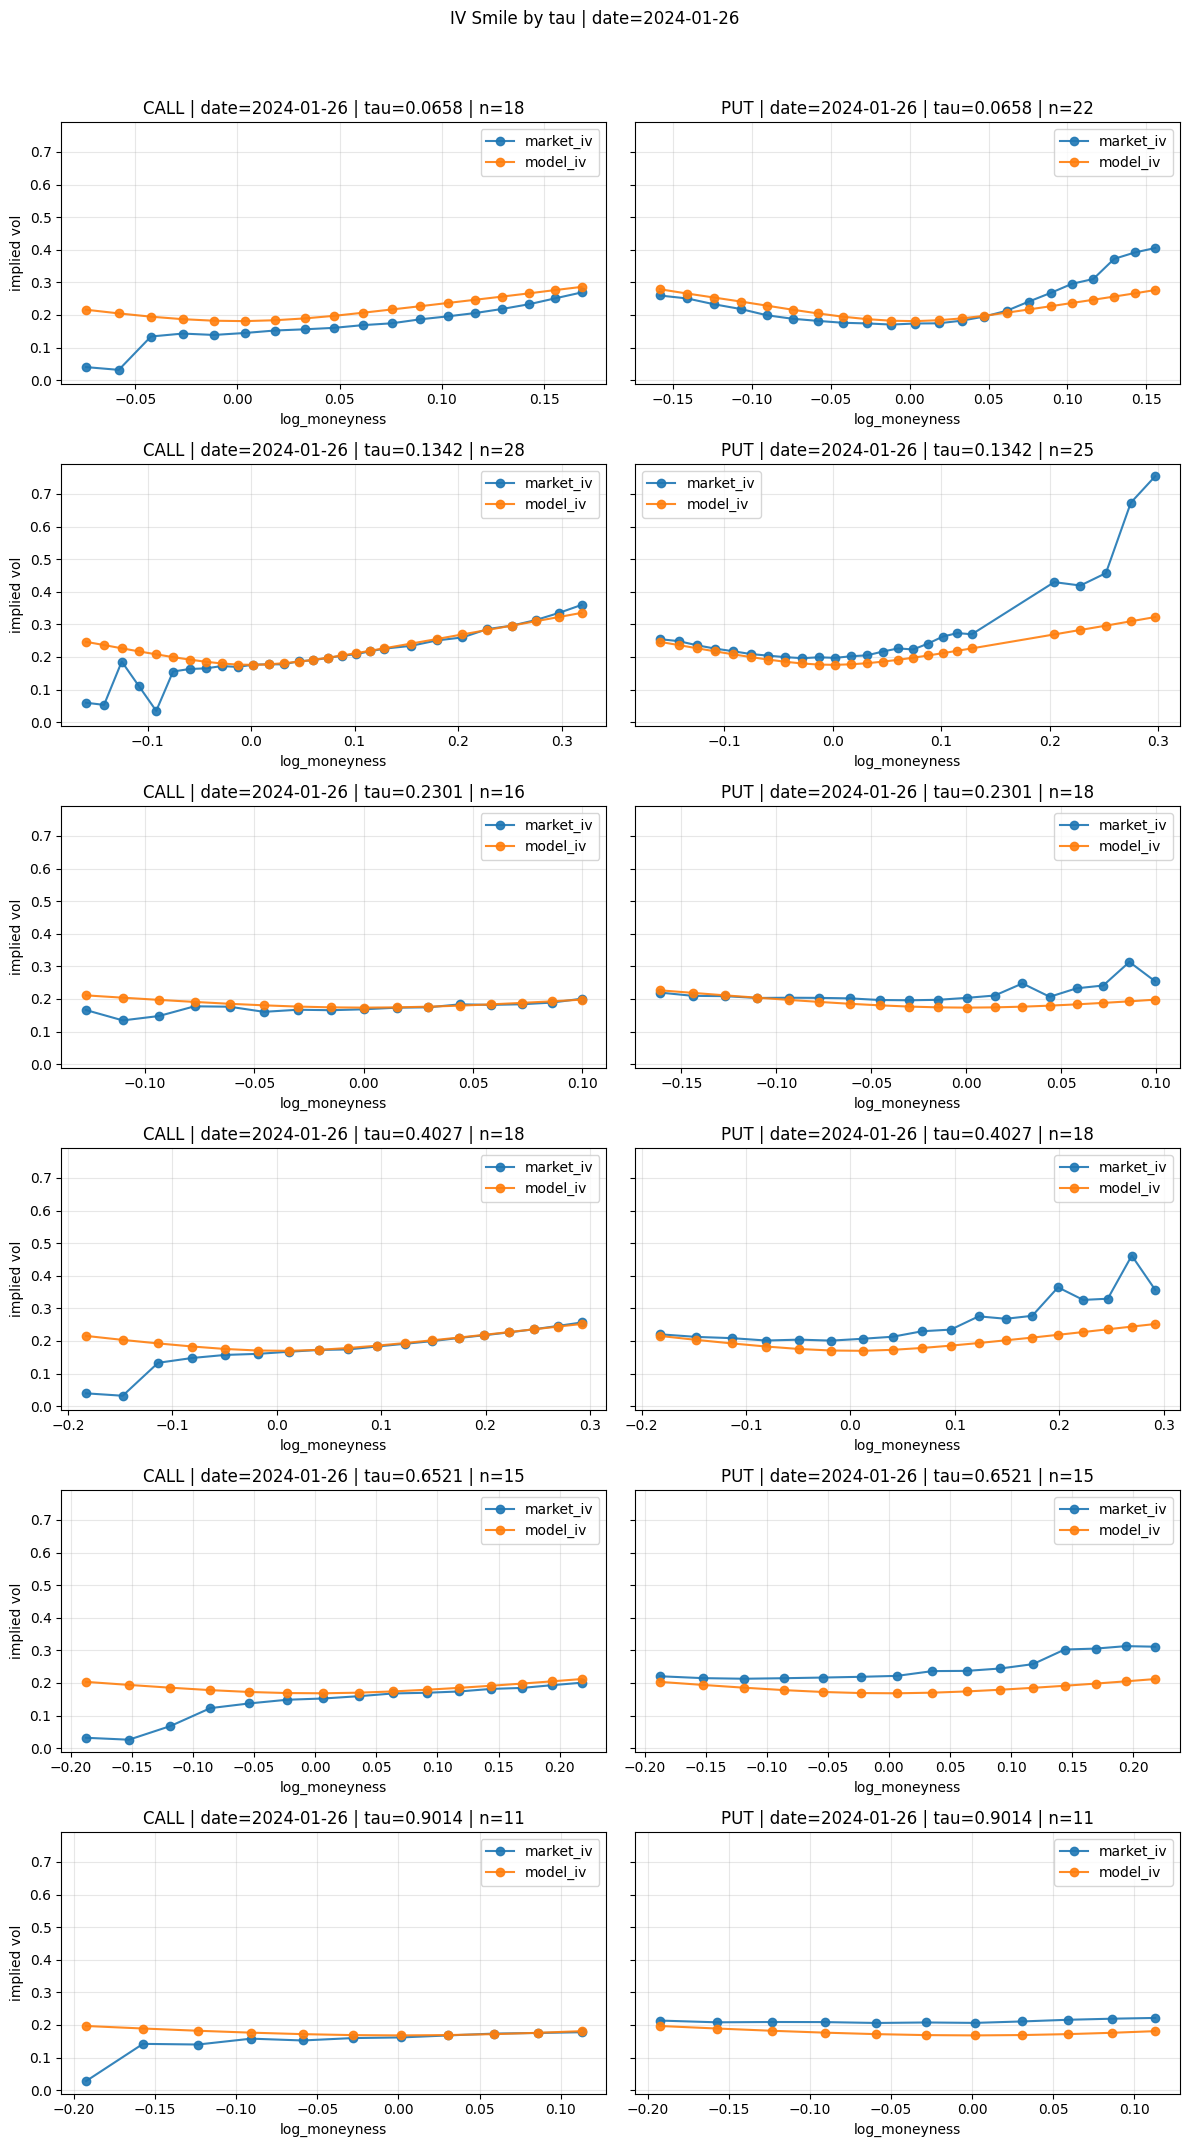

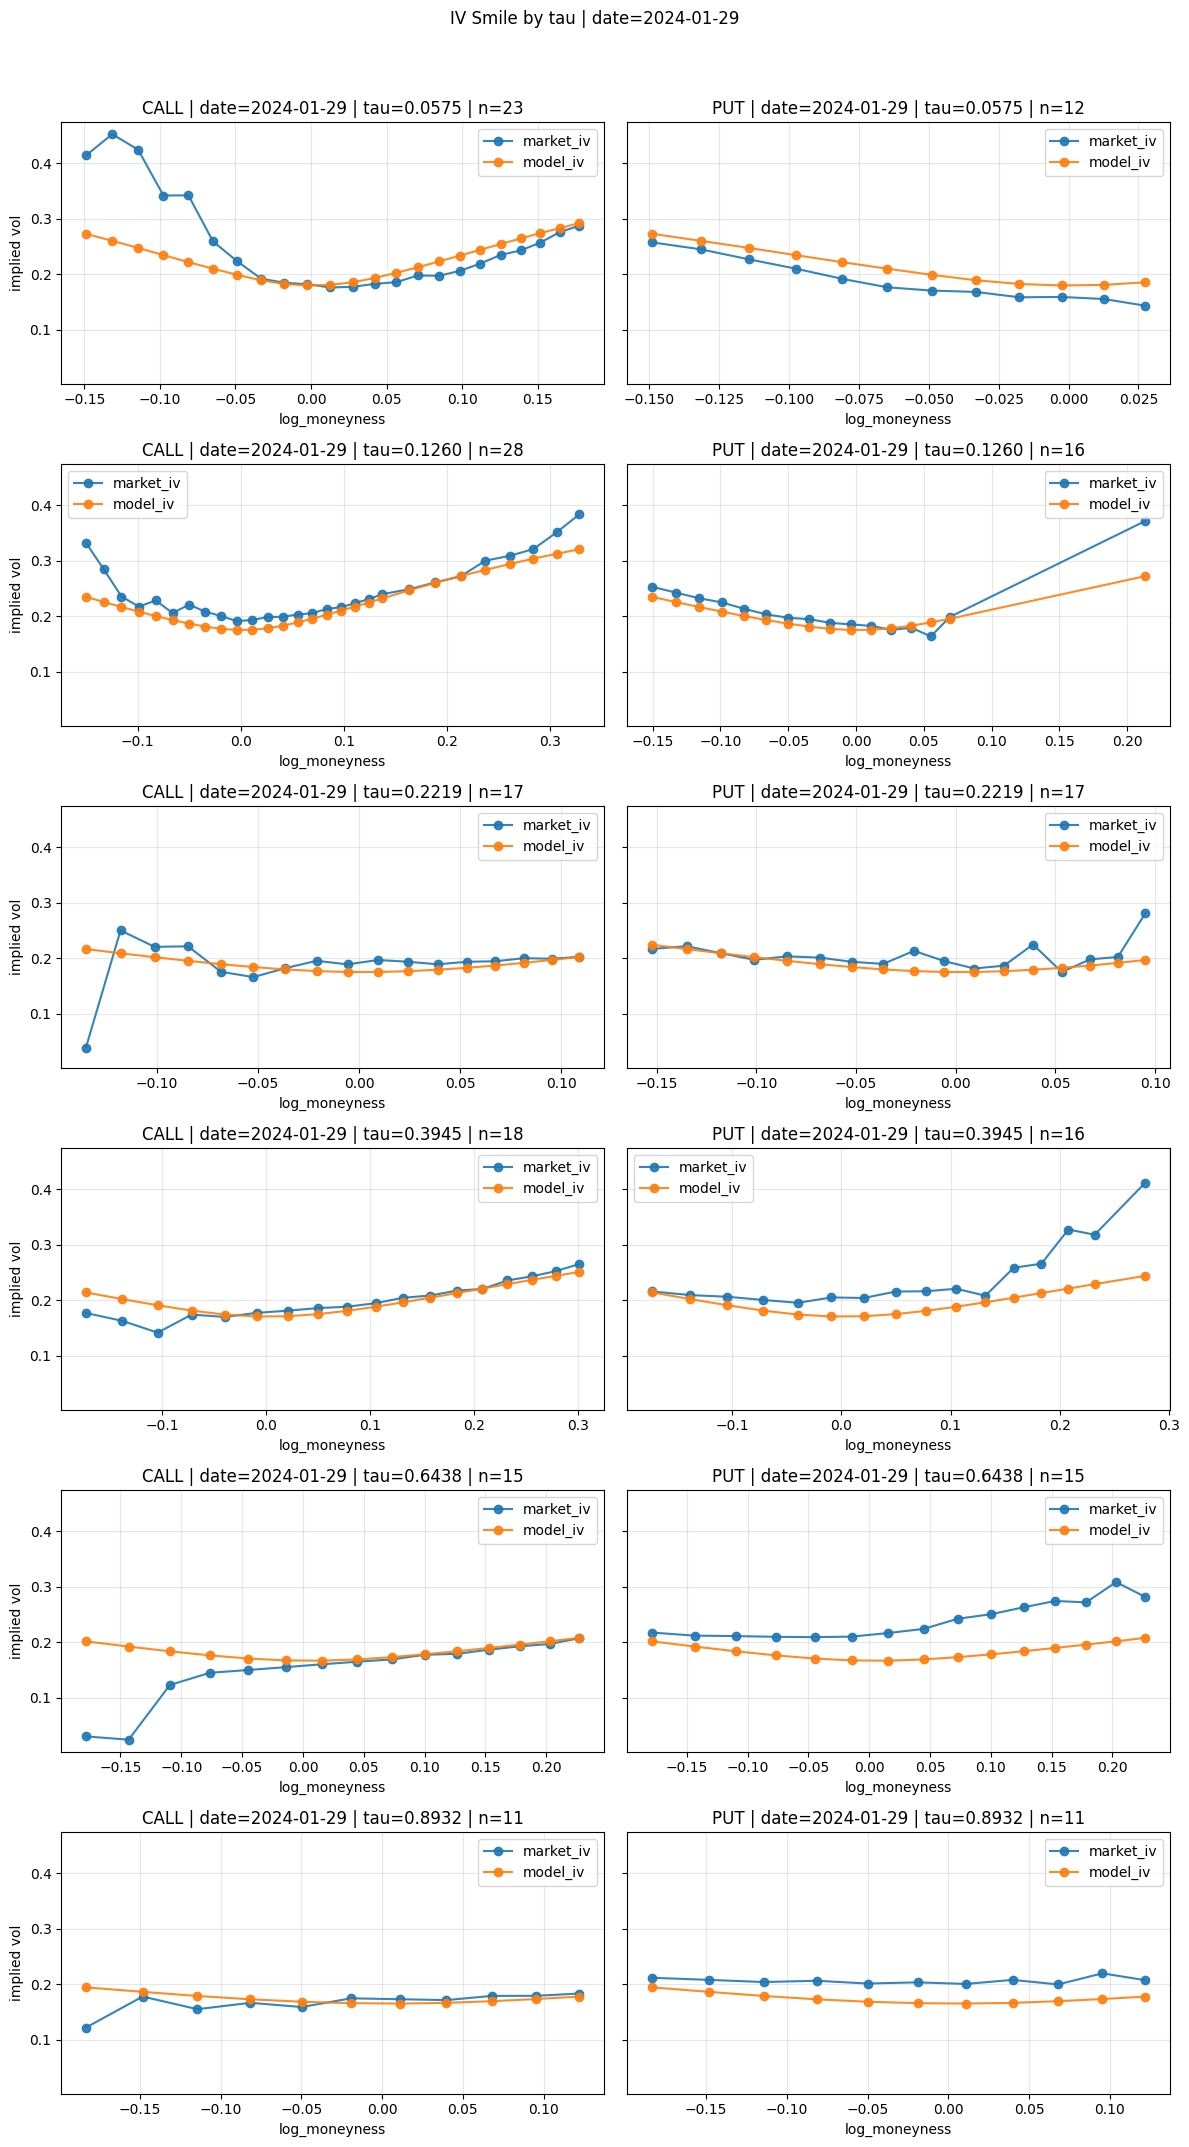

In [50]:
# 可视化1：按日期组织，每个交易日画该日所有到期的 call/put 对比
plot_df = result['rbergomi_test_df_with_rfsv_prior'].copy()
if plot_df.empty:
    print('No priced rows to plot.')
else:
    plot_df = plot_df.dropna(subset=['trade_date', 'maturity', 'log_moneyness', 'market_iv', 'model_iv']).copy()
    plot_df['trade_date'] = pd.to_datetime(plot_df['trade_date']).dt.normalize()

    date_list = sorted(plot_df['trade_date'].unique())
    if len(date_list) == 0:
        print('No dates to plot.')
    else:
        max_days = 12
        if len(date_list) <= max_days:
            selected_dates = date_list
        else:
            idx = np.linspace(0, len(date_list) - 1, max_days).round().astype(int)
            selected_dates = [date_list[i] for i in sorted(set(idx))]

        print(f'Selected {len(selected_dates)} dates to plot')
        for d in selected_dates:
            day_df = plot_df[plot_df['trade_date'] == d].copy()
            tau_list = sorted(day_df['maturity'].unique())

            if len(tau_list) == 0:
                print(f'date={pd.Timestamp(d).date()} (no data)')
                continue

            nrows = len(tau_list)
            fig, axes = plt.subplots(nrows, 2, figsize=(12, 3.5 * nrows), sharey=True)
            if nrows == 1:
                axes = axes.reshape(1, -1)

            for row, tau in enumerate(tau_list):
                slice_df = day_df[day_df['maturity'] == tau].sort_values('log_moneyness')

                for i, opt in enumerate(['call', 'put']):
                    ax = axes[row, i]
                    part = slice_df[slice_df['option_type'].str.lower() == opt].sort_values('log_moneyness')

                    if part.empty:
                        ax.set_title(f'{opt.upper()} (empty) | tau={tau:.4f}')
                        ax.grid(alpha=0.3)
                        continue

                    ax.plot(part['log_moneyness'], part['market_iv'], 'o-', label='market_iv', alpha=0.9)
                    ax.plot(part['log_moneyness'], part['model_iv'], 'o-', label='model_iv', alpha=0.9)
                    ax.set_title(f'{opt.upper()} | date={pd.Timestamp(d).date()} | tau={tau:.4f} | n={len(part)}')
                    ax.set_xlabel('log_moneyness')
                    ax.grid(alpha=0.3)
                    if i == 0:
                        ax.set_ylabel('implied vol')
                    ax.legend()

            fig.suptitle(f'IV Smile by tau | date={pd.Timestamp(d).date()}', y=1.02)
            plt.tight_layout()
            plt.show()

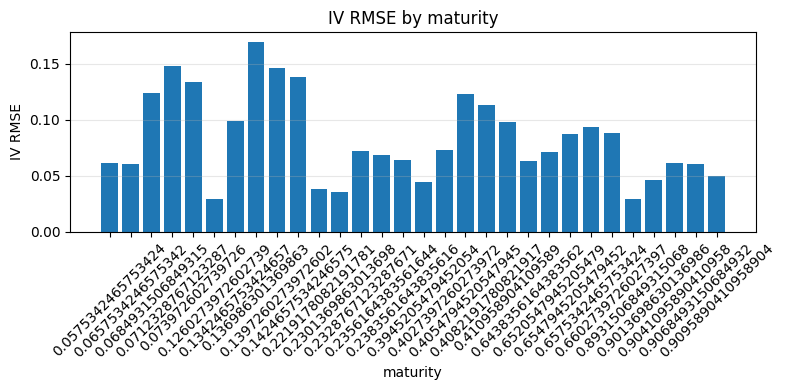

In [51]:
# 可视化2：按期限的 IV RMSE
cmp_df = result['rbergomi_test_df_with_rfsv_prior'].dropna(subset=['iv_error', 'maturity']).copy()
if cmp_df.empty:
    print('No IV errors to aggregate.')
else:
    rmse_by_tau = (
        cmp_df.groupby('maturity')['iv_error']
        .apply(lambda x: (x.pow(2).mean()) ** 0.5)
        .reset_index(name='iv_rmse')
        .sort_values('maturity')
    )

    plt.figure(figsize=(8, 4))
    plt.bar(rmse_by_tau['maturity'].astype(str), rmse_by_tau['iv_rmse'])
    plt.title('IV RMSE by maturity')
    plt.xlabel('maturity')
    plt.ylabel('IV RMSE')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    rmse_by_tau.head()